# Qué hay en el caché de ventanas

Recorre el caché que deja `src/prepare_data.py`: metadatos, tamaño de cada split, fuga de
grabaciones, distribución de clases, geometría de las cajas y algunas ventanas dibujadas.

`CACHE_DIR` apunta al caché nuevo; cambiándolo a `data/processed` el notebook corre igual
sobre el viejo y sirve para comparar.

In [1]:
import json
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from core.config import P, settings

CACHE_DIR = PROJECT_DIR / "data" / "processed_v2"

settings.PROJECT_DIR = PROJECT_DIR
settings.PROCESSED_DIR = CACHE_DIR

from data import cache  # noqa: E402  -- lee settings.processed_dir en cada llamada
from utils.audio import mel_to_db, mel_to_unit, y_to_hz  # noqa: E402

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
print(CACHE_DIR)

/home/nhrot/Prog/tesis-primate/data/processed_v2


In [2]:
# --- Estilo, el mismo de dataset_report.ipynb --------------------------------
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_2 = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"

SPLIT_COLOR = {"train": "#2a78d6", "val": "#eb6834", "test": "#1baf7a"}
BLUE = "#2a78d6"
BLUE_FADED = "#b7d3f6"
CRITICAL = "#d03b3b"

mpl.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "savefig.dpi": 140,
        "savefig.bbox": "tight",
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans"],
        "font.size": 9,
        "text.color": INK,
        "axes.edgecolor": BASELINE,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 14,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "xtick.major.size": 0,
        "ytick.major.size": 0,
        "legend.frameon": False,
        "legend.fontsize": 8.5,
        "lines.linewidth": 2,
    }
)


def value_grid(ax, axis="y"):
    ax.grid(True, axis=axis, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["bottom" if axis == "y" else "left"].set_visible(False)

## 1. Metadatos

`meta.json` es el contrato entre el caché y todo lo que lo consume: los `db_range` con los
que YOLO y Faster R-CNN pasan el mel a imagen, la normalización medida sobre train y los
`Parameters` con los que se calculó cada espectrograma.

In [3]:
meta = cache.meta()
labels = cache.labels()

print(f"{len(labels)} clases: {', '.join(labels.names)}")
print(f"db_range: {meta['db_range'][0]:.2f} .. {meta['db_range'][1]:.2f} dB")
print(f"normalización (train): mean={meta['normalization']['mean']:.4f} "
      f"std={meta['normalization']['std']:.4f}")

selection = {k: meta[k] for k in ("seed", "min_pair_count", "max_classes", "empty_ratio", "label_by")}
pd.Series(selection | {"excluded_pairs": ", ".join("/".join(p) for p in meta["excluded_pairs"])}).to_frame("valor")

25 clases: aa/gc, aa/hm, aa/sc, ac/bc, ac/chc, ac/gc, ac/sc, as/bc, as/hc, lw/cs, lw/sqc, lw/ta, lw/trino, lw/vc, pt/dc, pt/sqc, sb/pcc, sb/ppc, sb/sc, sb/spc, sm/cc, sm/fs, sm/hic, sm/pc, sm/sc
db_range: -54.68 .. 29.29 dB
normalización (train): mean=4.4561 std=183.6589


,valor
seed,42
min_pair_count,100
max_classes,None
empty_ratio,0.250
label_by,species/call_type
excluded_pairs,"lw/cc, sb/pcs, sm/fc"


In [4]:
# Los `Parameters` de este caché contra los que tiene el código hoy: si alguna fila
# difiere, el caché es de otra versión y hay que regenerarlo antes de entrenar.
from dataclasses import asdict  # noqa: E402

cached, current = meta["params"], asdict(P)
params = pd.DataFrame(
    {"en el caché": pd.Series(cached), "en el código": pd.Series(current)}
).astype(object)
params["igual"] = [
    "—" if pd.isna(a) or pd.isna(b) else ("sí" if a == b else "NO")
    for a, b in zip(params["en el caché"], params["en el código"], strict=True)
]
params

,en el caché,en el código,igual
clip_len_s,3.000,3.000,sí
clip_hop_s,1.500,1.500,sí
min_overlap,0.500,0.500,sí
pad_seed,0,0,sí
target_sr,44100,44100,sí
n_fft,4096,4096,sí
win_length,1024,1024,sí
hop_length,400,400,sí
n_mels,128,128,sí
f_min,25.000,25.000,sí


## 2. Tamaño de cada split

Se abre con `mmap=True`: las imágenes son ~6 GB entre los tres splits y así el notebook
sólo trae a memoria las ventanas que efectivamente mira.

In [5]:
splits = {
    name: torch.load(cache.split_path(name), mmap=True, weights_only=False)
    for name in cache.SPLITS
}
recordings = {
    name: json.loads(cache.sources_path(name).read_text())["recordings"]
    for name in cache.SPLITS
}

rows = []
for name, data in splits.items():
    n_boxes = np.array([len(b) for b in data["boxes"]])
    rows.append(
        {
            "split": name,
            "ventanas": len(data["images"]),
            "cajas": int(n_boxes.sum()),
            "ventanas vacías": int((n_boxes == 0).sum()),
            "% vacías": 100 * (n_boxes == 0).mean(),
            "cajas/ventana con caja": n_boxes[n_boxes > 0].mean(),
            "grabaciones": len(recordings[name]),
            "GB": cache.split_path(name).stat().st_size / 1024**3,
        }
    )

summary = pd.DataFrame(rows).set_index("split")
summary.loc["total"] = summary.sum()
summary.loc["total", "cajas/ventana con caja"] = np.nan
summary.loc["total", "% vacías"] = 100 * summary.loc["total", "ventanas vacías"] / summary.loc["total", "ventanas"]
summary

,ventanas,cajas,ventanas vacías,% vacías,cajas/ventana con caja,grabaciones,GB
split,,,,,,,
train,"21,966.000","27,022.000","4,585.000",20.873,1.555,"1,314.000",3.477
val,"9,446.000","10,090.000","2,712.000",28.711,1.498,728.000,1.495
test,"8,007.000","7,985.000","2,558.000",31.947,1.465,627.000,1.267
total,"39,419.000","45,097.000","9,855.000",25.001,NaN,"2,669.000",6.240


In [6]:
image_shape = tuple(splits["train"]["images"].shape[1:])
print(f"cada ventana: {image_shape} (1 canal, {P.n_mels} mels, {P.n_frames} frames)")
print(f"{P.clip_len_s} s por ventana, hop {P.clip_hop_s} s, {P.target_sr} Hz")
print(f"horas de audio materializadas: {summary.loc['total', 'ventanas'] * P.clip_len_s / 3600:.1f}")

cada ventana: (1, 128, 331) (1 canal, 128 mels, 331 frames)
3.0 s por ventana, hop 1.5 s, 44100 Hz
horas de audio materializadas: 32.8


## 3. Fuga entre splits

`split_manifest` reparte por archivo de audio, no por ventana: dos ventanas solapadas de la
misma grabación no pueden caer una en train y otra en test. Esto lo verifica.

In [7]:
sets = {name: set(paths) for name, paths in recordings.items()}
leaks = {
    f"{a} ∩ {b}": len(sets[a] & sets[b])
    for a, b in [("train", "val"), ("train", "test"), ("val", "test")]
}
print(leaks)
print("sin fuga" if not any(leaks.values()) else "¡HAY GRABACIONES COMPARTIDAS!")


{'train ∩ val': 0, 'train ∩ test': 0, 'val ∩ test': 0}
sin fuga


## 4. Distribución de clases

Cuántas cajas de cada clase cayeron en cada split. Las clases raras son las que más se
desvían del reparto nominal: un puñado de grabaciones las concentra y el reparto por
archivo no puede partirlas.

In [8]:
counts = pd.DataFrame(
    {
        name: pd.Series(
            np.bincount(
                torch.cat(data["labels"]).numpy() if data["labels"] else np.array([], dtype=int),
                minlength=len(labels),
            ),
            index=labels.names,
        )
        for name, data in splits.items()
    }
)
counts["total"] = counts.sum(axis=1)
for name in cache.SPLITS:
    counts[f"% {name}"] = 100 * counts[name] / counts["total"]
counts.sort_values("total", ascending=False)

,train,val,test,total,% train,% val,% test
as/hc,6933,2601,2023,11557,59.990,22.506,17.505
ac/bc,2886,1082,842,4810,60.000,22.495,17.505
lw/cs,2706,1014,792,4512,59.973,22.473,17.553
sm/cc,2359,884,688,3931,60.010,22.488,17.502
as/bc,2233,837,651,3721,60.011,22.494,17.495
pt/dc,1950,731,568,3249,60.018,22.499,17.482
sb/ppc,1300,463,472,2235,58.166,20.716,21.119
aa/gc,924,347,269,1540,60.000,22.532,17.468
sb/spc,860,323,251,1434,59.972,22.524,17.503
sm/fs,801,299,232,1332,60.135,22.447,17.417


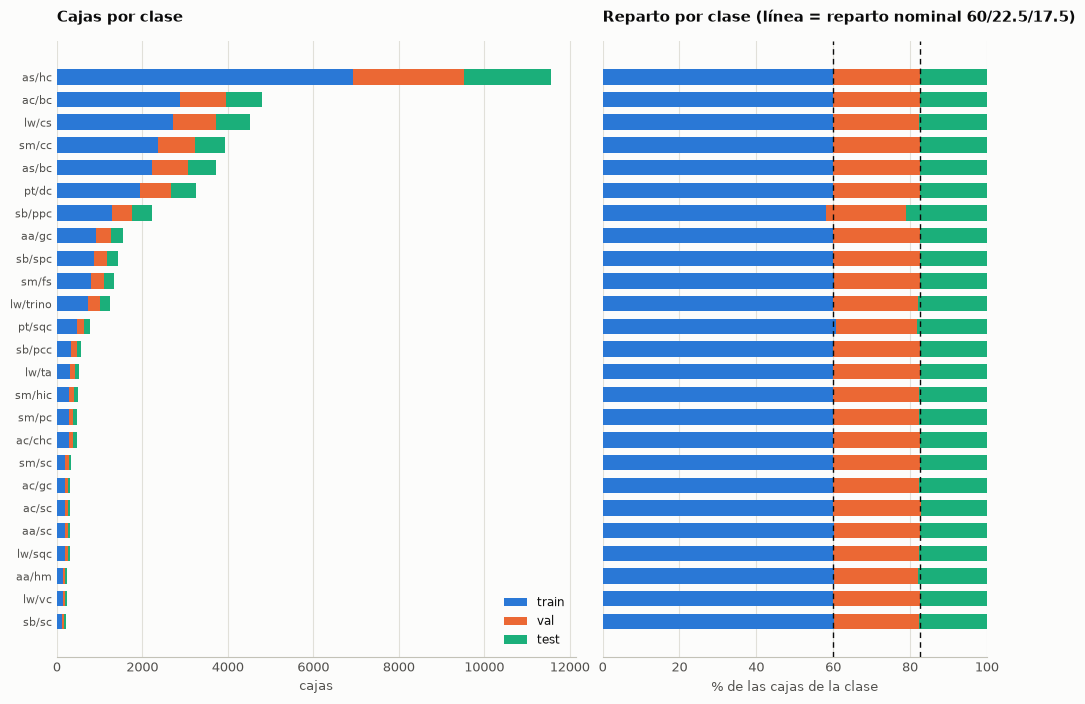

In [9]:
order = counts.sort_values("total").index
ys = np.arange(len(order))

fig, axes = plt.subplots(1, 2, figsize=(12, 8), gridspec_kw={"wspace": 0.06, "width_ratios": [1.35, 1]})

ax = axes[0]
left = np.zeros(len(order))
for name in cache.SPLITS:
    values = counts.loc[order, name].to_numpy(dtype=float)
    ax.barh(ys, values, left=left, height=0.68, color=SPLIT_COLOR[name], label=name)
    left += values
ax.set_yticks(ys, order, fontsize=8)
ax.set_xlabel("cajas")
ax.set_title("Cajas por clase")
ax.legend(loc="lower right")
value_grid(ax, "x")

ax = axes[1]
left = np.zeros(len(order))
for name in cache.SPLITS:
    values = counts.loc[order, f"% {name}"].to_numpy(dtype=float)
    ax.barh(ys, values, left=left, height=0.68, color=SPLIT_COLOR[name])
    left += values
nominal = np.cumsum([60, 22.5])  # SPLIT_RATIOS de prepare_data.py
for x in nominal:
    ax.axvline(x, color=INK, linewidth=1, linestyle=(0, (4, 3)), zorder=3)
ax.set_yticks(ys, [])
ax.set_xlim(0, 100)
ax.set_xlabel("% de las cajas de la clase")
ax.set_title("Reparto por clase (línea = reparto nominal 60/22.5/17.5)")
value_grid(ax, "x")
plt.show()

## 5. Geometría de las cajas

Las cajas del caché son `cxcywh` normalizadas al clip: `x` es tiempo sobre los 3 s y `y` es
frecuencia en el eje mel, no en Hz. Acá se devuelven a segundos y a Hz para poder leerlas.

In [10]:
boxes = {
    name: torch.cat([b for b in data["boxes"] if len(b)]).numpy()
    for name, data in splits.items()
}
all_boxes = np.concatenate(list(boxes.values()))
all_labels = torch.cat([torch.cat(d["labels"]) for d in splits.values()]).numpy()

geometry = pd.DataFrame(
    {
        "clase": [labels.name(i) for i in all_labels],
        "duracion_s": all_boxes[:, 2] * P.clip_len_s,
        "freq_baja_hz": y_to_hz(all_boxes[:, 1] - all_boxes[:, 3] / 2, P),
        "freq_alta_hz": y_to_hz(all_boxes[:, 1] + all_boxes[:, 3] / 2, P),
        "toca_borde_t": (all_boxes[:, 0] - all_boxes[:, 2] / 2 <= 1e-6)
        | (all_boxes[:, 0] + all_boxes[:, 2] / 2 >= 1 - 1e-6),
    }
)
geometry["ancho_banda_hz"] = geometry.freq_alta_hz - geometry.freq_baja_hz

print(f"{len(geometry):,} cajas | {100 * geometry.toca_borde_t.mean():.1f}% tocan un borde temporal "
      "(la llamada sigue fuera de la ventana)")
geometry.groupby("clase").agg(
    n=("duracion_s", "size"),
    dur_mediana_s=("duracion_s", "median"),
    dur_q90_s=("duracion_s", lambda s: s.quantile(0.9)),
    freq_baja_mediana_hz=("freq_baja_hz", "median"),
    freq_alta_mediana_hz=("freq_alta_hz", "median"),
    banda_mediana_hz=("ancho_banda_hz", "median"),
).sort_values("n", ascending=False)

45,097 cajas | 40.6% tocan un borde temporal (la llamada sigue fuera de la ventana)


,n,dur_mediana_s,dur_q90_s,freq_baja_mediana_hz,freq_alta_mediana_hz,banda_mediana_hz
clase,,,,,,
as/hc,11557,3.000,3.000,49.497,784.066,729.890
ac/bc,4810,0.332,0.588,374.377,"2,615.547","2,234.300"
lw/cs,4512,0.413,0.560,"8,035.201","10,205.599","2,094.767"
sm/cc,3931,0.081,0.138,523.442,"3,600.650","3,064.456"
as/bc,3721,0.315,0.518,105.111,667.095,565.200
pt/dc,3249,3.000,3.000,44.000,"1,473.200","1,382.400"
sb/ppc,2235,0.195,0.379,"6,969.827","11,234.600","3,924.154"
aa/gc,1540,0.093,0.143,97.351,"3,071.221","2,852.679"
sb/spc,1434,0.159,0.278,246.800,"15,935.839","15,603.775"


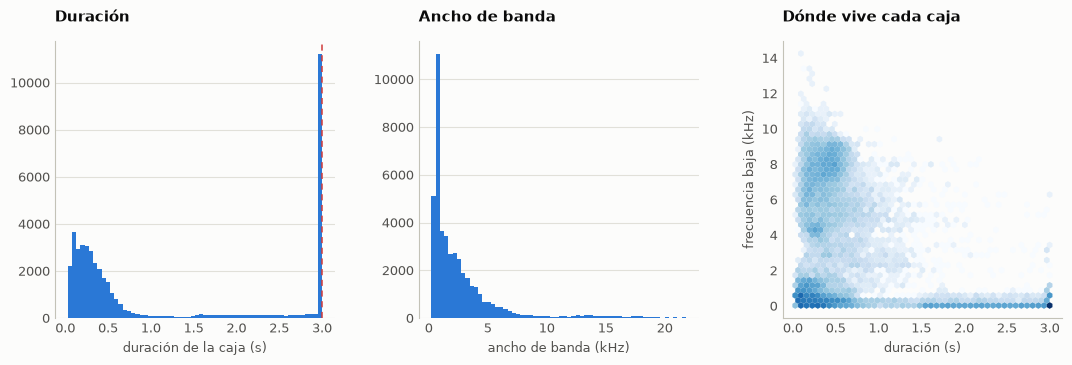

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), gridspec_kw={"wspace": 0.3})

ax = axes[0]
ax.hist(geometry.duracion_s, bins=60, color=BLUE, edgecolor="none")
ax.axvline(P.clip_len_s, color=CRITICAL, linewidth=1.1, linestyle=(0, (4, 3)))
ax.set_xlabel("duración de la caja (s)")
ax.set_title("Duración")
value_grid(ax)

ax = axes[1]
ax.hist(geometry.ancho_banda_hz / 1000, bins=60, color=BLUE, edgecolor="none")
ax.set_xlabel("ancho de banda (kHz)")
ax.set_title("Ancho de banda")
value_grid(ax)

ax = axes[2]
ax.hexbin(
    geometry.duracion_s,
    geometry.freq_baja_hz / 1000,
    gridsize=45,
    bins="log",
    cmap="Blues",
    linewidths=0,
)
ax.set_xlabel("duración (s)")
ax.set_ylabel("frecuencia baja (kHz)")
ax.set_title("Dónde vive cada caja")
plt.show()

## 6. Rango dinámico

`db_range` son los percentiles 1 y 99.9 de una muestra de ventanas de train, y es el
intervalo que `mel_to_gray` mapea a 0-255. Lo que quede afuera se satura: acá se ve cuánto.

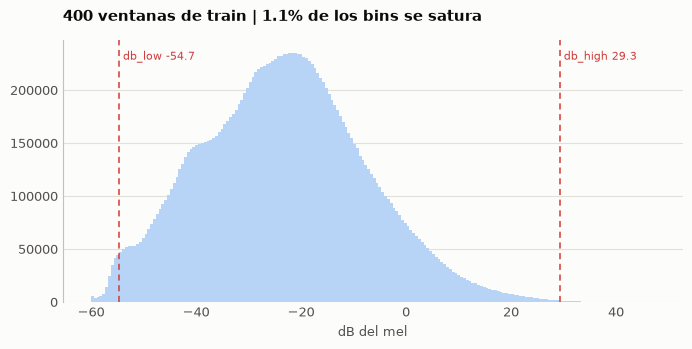

In [12]:
db_low, db_high = cache.db_range()
sample = np.random.default_rng(meta["seed"]).choice(len(splits["train"]["images"]), 400, replace=False)
db = mel_to_db(splits["train"]["images"][np.sort(sample)][:, 0].float()).numpy().ravel()

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(db, bins=200, color=BLUE_FADED, edgecolor="none")
for x, text in [(db_low, f"db_low {db_low:.1f}"), (db_high, f"db_high {db_high:.1f}")]:
    ax.axvline(x, color=CRITICAL, linewidth=1.1, linestyle=(0, (4, 3)))
    ax.text(x, ax.get_ylim()[1] * 0.96, f" {text}", color=CRITICAL, fontsize=8, va="top")
ax.set_xlabel("dB del mel")
ax.set_title(f"{len(sample)} ventanas de train | "
             f"{100 * ((db < db_low) | (db > db_high)).mean():.1f}% de los bins se satura")
value_grid(ax)
plt.show()

## 7. Ventanas de ejemplo

Lo que el detector ve de verdad: el mel llevado a [0, 1] con `db_range` y las cajas del
caché encima. El eje de frecuencia es el mel, así que las marcas no van equiespaciadas en Hz.

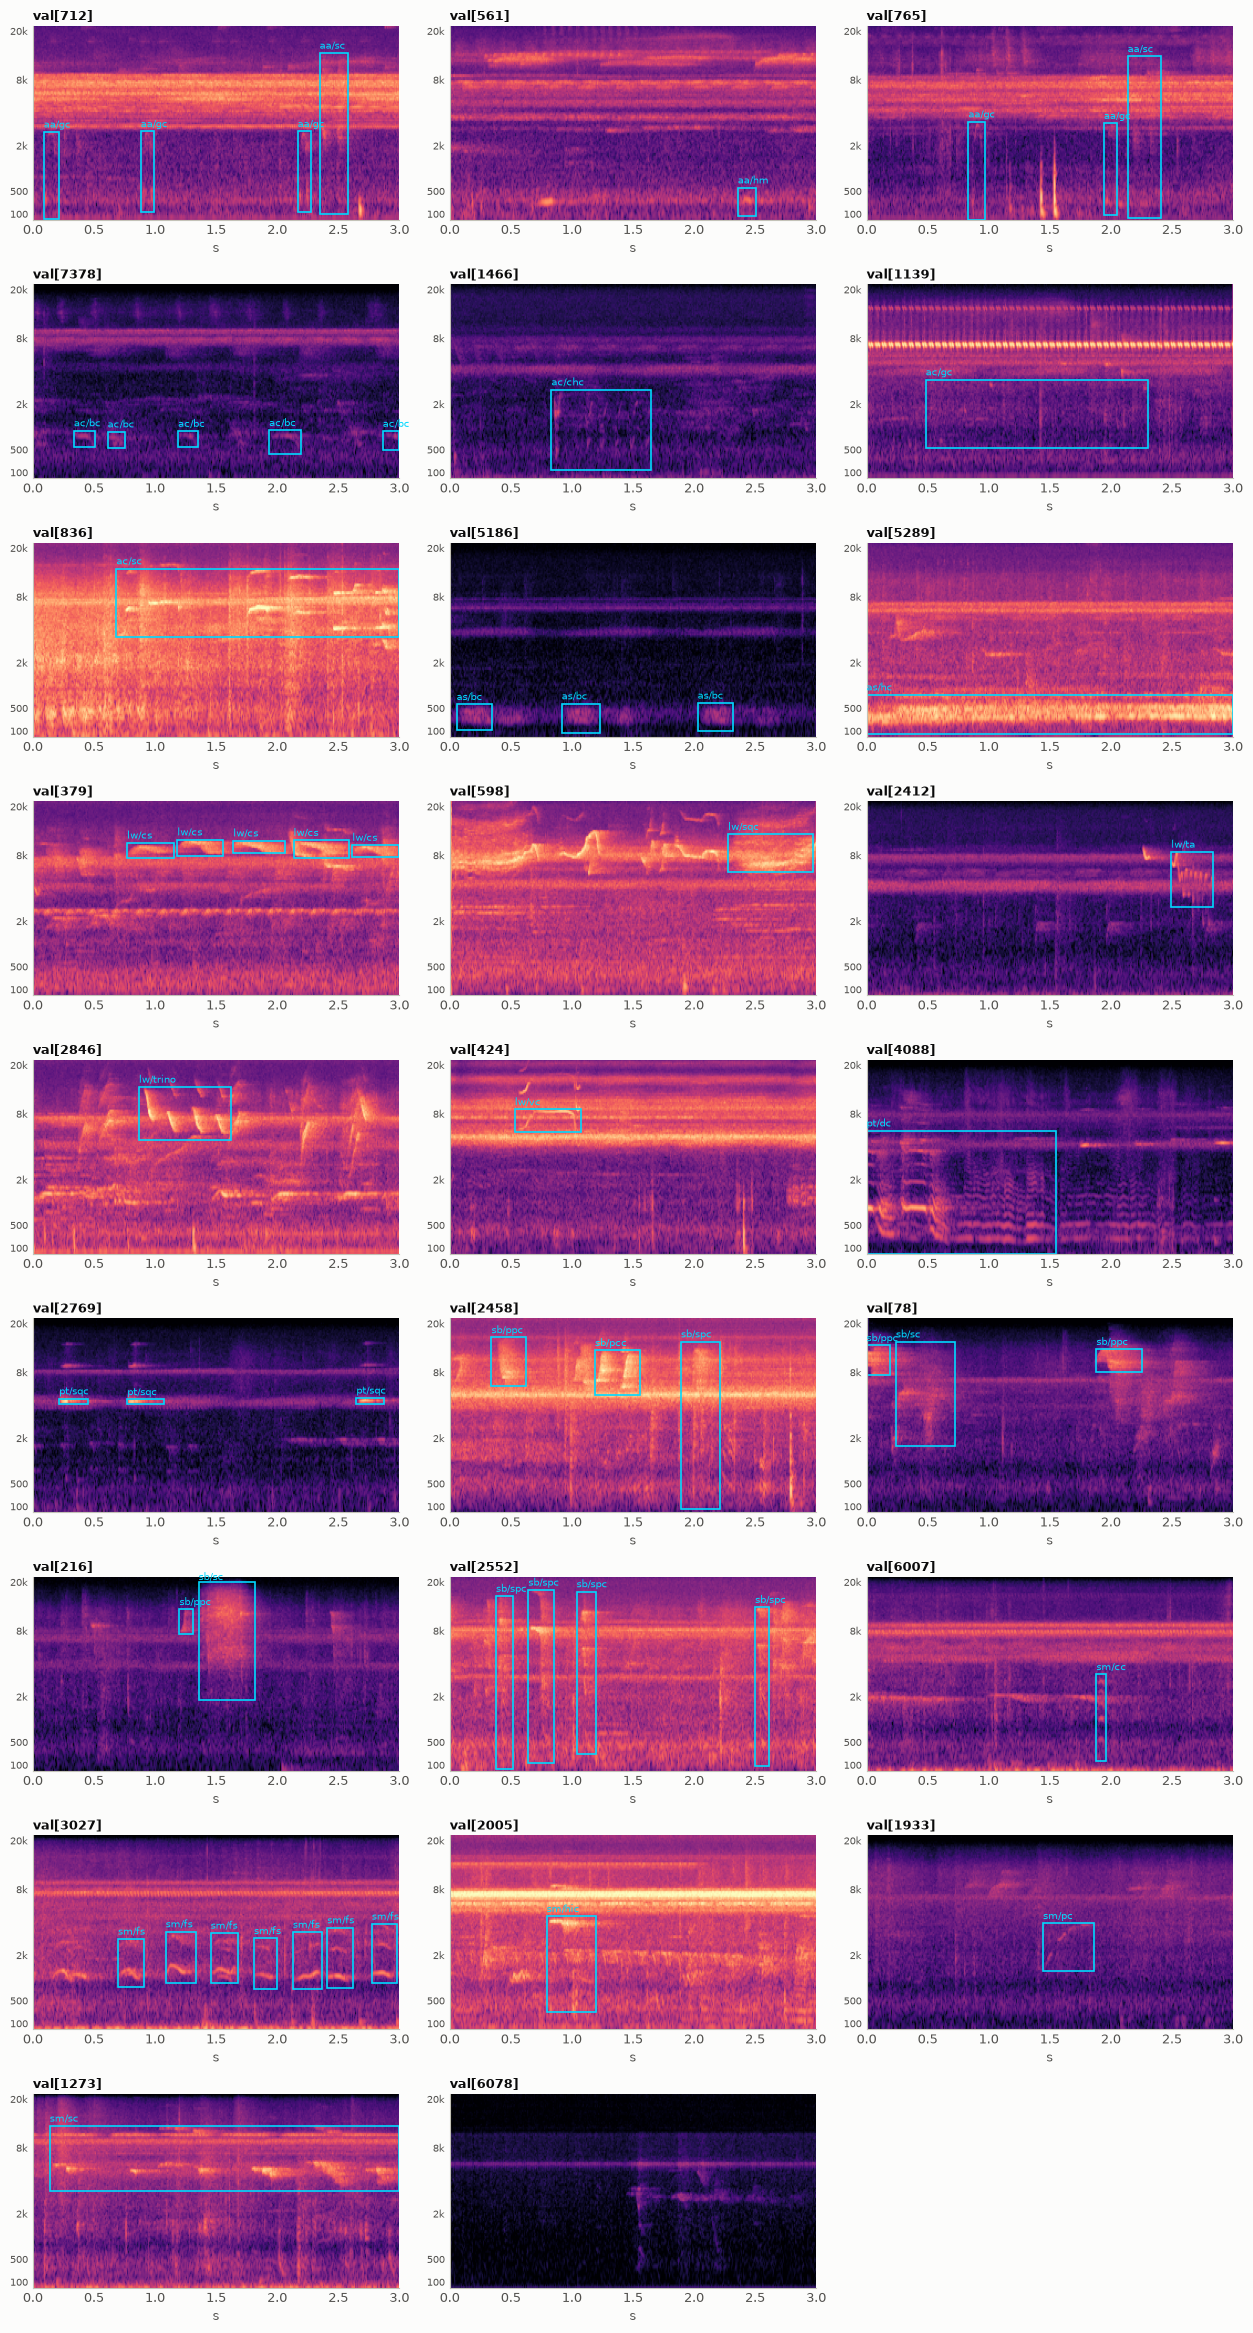

In [13]:
YTICKS_HZ = [100, 500, 2000, 8000, 20000]


def draw_window(ax, split, index):
    data = splits[split]
    mel = data["images"][index][0].float()
    ax.imshow(
        mel_to_unit(mel, db_low, db_high).numpy(),
        origin="lower",
        aspect="auto",
        cmap="magma",
        extent=(0, P.clip_len_s, 0, 1),
        vmin=0,
        vmax=1,
    )
    for (cx, cy, w, h), class_id in zip(data["boxes"][index].tolist(), data["labels"][index].tolist(), strict=True):
        ax.add_patch(
            plt.Rectangle(
                ((cx - w / 2) * P.clip_len_s, cy - h / 2),
                w * P.clip_len_s,
                h,
                fill=False,
                edgecolor="#00d8ff",
                linewidth=1.2,
            )
        )
        ax.text(
            (cx - w / 2) * P.clip_len_s,
            min(cy + h / 2 + 0.01, 0.97),
            labels.name(class_id),
            color="#00d8ff",
            fontsize=7,
            va="bottom",
        )
    ax.set_title(f"{split}[{index}]", fontsize=9, pad=4)
    ax.set_xlabel("s")
    y = (np.log10(1 + np.array(YTICKS_HZ, dtype=float) / P.mel_break_hz) - np.log10(1 + P.f_min / P.mel_break_hz))
    y /= np.log10(1 + P.f_max / P.mel_break_hz) - np.log10(1 + P.f_min / P.mel_break_hz)
    ax.set_yticks(y, [f"{hz / 1000:g}k" if hz >= 1000 else str(hz) for hz in YTICKS_HZ], fontsize=7)


# Una ventana por clase, la primera que la contenga, más una vacía al final.
rng = np.random.default_rng(meta["seed"])
picks = []
for class_id in range(len(labels)):
    hits = [i for i, lab in enumerate(splits["val"]["labels"]) if class_id in lab.tolist()]
    if hits:
        picks.append(("val", int(rng.choice(hits))))
empty = [i for i, b in enumerate(splits["val"]["boxes"]) if not len(b)]
picks.append(("val", int(rng.choice(empty))))

n_cols = 3
n_rows = int(np.ceil(len(picks) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 2.6 * n_rows))
for ax, (split, index) in zip(axes.ravel(), picks, strict=False):
    draw_window(ax, split, index)
for ax in axes.ravel()[len(picks):]:
    ax.axis("off")
fig.tight_layout()
plt.show()